# **Fake News Detection Using NLP & Machine Learning**

##### *A machine learning system that analyzes the textual patterns of news articles using Natural Language Processing (NLP) and predicts whether a given article is likely real or fake. The project covers the complete pipeline from data exploration and text preprocessing to feature extraction, model training, evaluation, and eventually real-time prediction through a user-facing application.*

## **1. Importing all libraries required for this project**

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score,confusion_matrix,recall_score, ConfusionMatrixDisplay,accuracy_score, classification_report,precision_score
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")
import joblib

## **2. Loading Dataset**

In [3]:
real_dataset=pd.read_csv("True.csv")
fake_dataset=pd.read_csv("Fake.csv")

#### Real Dataset

In [4]:
real_dataset.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


#### Fake Dataset

In [5]:
fake_dataset.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## **3.Extracting information about dataset**

In [6]:
real_dataset.shape


(21417, 4)

In [7]:
fake_dataset.shape

(23481, 4)

In [8]:
real_dataset.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [9]:
fake_dataset.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [10]:
real_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


In [11]:
fake_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


In [12]:
real_dataset.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [13]:
fake_dataset.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [14]:
print(real_dataset.duplicated().sum())
print(fake_dataset.duplicated().sum())

206
3


#### **Making a new column "lable"** 

#### Assigning label 1 to the real dataset

In [15]:
real_dataset['label']=1

#### Assigning label 0 to the fake dataset

In [16]:
fake_dataset['label']=0

In [17]:
real_dataset=real_dataset.drop_duplicates()

In [18]:
fake_dataset=fake_dataset.drop_duplicates()

#### **Merging both dataset**

In [19]:
df=pd.concat([real_dataset,fake_dataset],ignore_index=True)

#### **Extracting information about merged dataset**

In [20]:
df.shape

(44689, 5)

In [21]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [22]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

In [23]:
df.describe()

,label
count,44689.000000
mean,0.474636
std,0.499362
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44689 non-null  str  
 1   text     44689 non-null  str  
 2   subject  44689 non-null  str  
 3   date     44689 non-null  str  
 4   label    44689 non-null  int64
dtypes: int64(1), str(4)
memory usage: 111.7 MB


In [25]:
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [26]:
df.tail()

,title,text,subject,date,label
44684,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44685,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44686,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44687,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
44688,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [27]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [28]:
df.head()

,title,text,subject,date,label
0,"Merkel, Juncker discuss Catalan crisis: EU off...",BRUSSELS (Reuters) - German Chancellor Angela ...,worldnews,"October 7, 2017",1
1,LIBERAL HACK KATIE COURIC Says Fake News Is “T...,Katie Couric is a wolf in sheep s clothing. Da...,left-news,"Jul 22, 2017",0
2,TRUMP WAS RIGHT! Audit Reveals State Dept. Cyb...,New documents appear to show a pattern of dete...,politics,"Oct 19, 2015",0
3,Clay Aiken Says He Was A ‘F*****g Dumbass’ Fo...,Former American Idol finalist and Celebrity...,News,"August 16, 2017",0
4,U.S. militia girds for trouble as presidential...,"JACKSON, Ga. (Reuters) - Down a Georgia count...",politicsNews,"November 2, 2016",1


In [29]:
df.value_counts(['label'])

label
0        23478
1        21211
Name: count, dtype: int64

In [30]:
df.columns.dtype

<StringDtype(na_value=nan)>

## **4. Performing EDA**

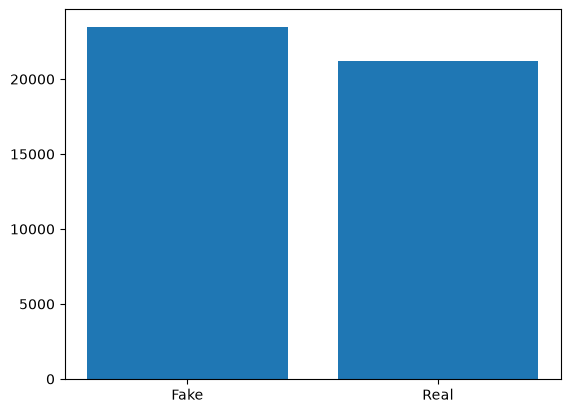

In [31]:
plt.bar([0, 1], df['label'].value_counts())
plt.xticks([0, 1], ['Fake', 'Real'])
plt.show()

In [32]:
df['title_length'] = df['title'].str.len()
avg_title_length = df.groupby('label')['title_length'].mean()
print(avg_title_length)

label
0    94.194054
1    64.658291
Name: title_length, dtype: float64


##### **Signifies that avg. lenght of fake dataset title is more**

In [33]:
df['text_length'] = df['text'].str.len()
df.groupby('label')['text_length'].mean()


label
0    2547.555882
1    2378.042337
Name: text_length, dtype: float64

##### **Signifies that avg. lenght of fake dataset text is more**

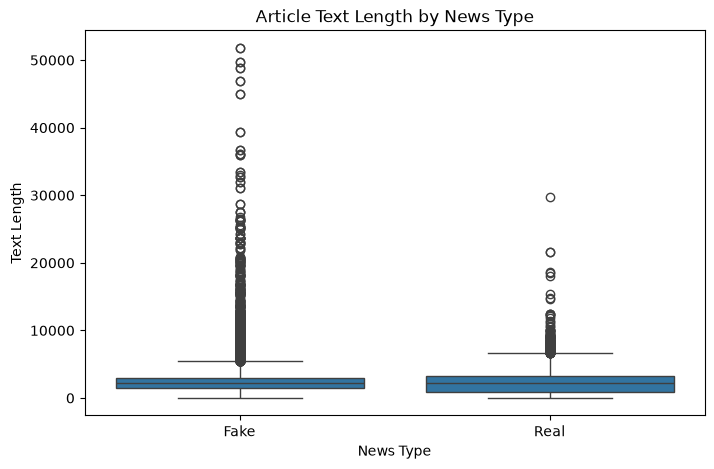

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='text_length', data=df)
plt.xticks([0,1], ['Fake', 'Real'])
plt.title('Article Text Length by News Type')
plt.xlabel('News Type')
plt.ylabel('Text Length')
plt.show()

In [35]:
subject_label = pd.crosstab(df['subject'], df['label'])
print(subject_label)

label               0      1
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6838      0
politicsNews        0  11220
worldnews           0   9991


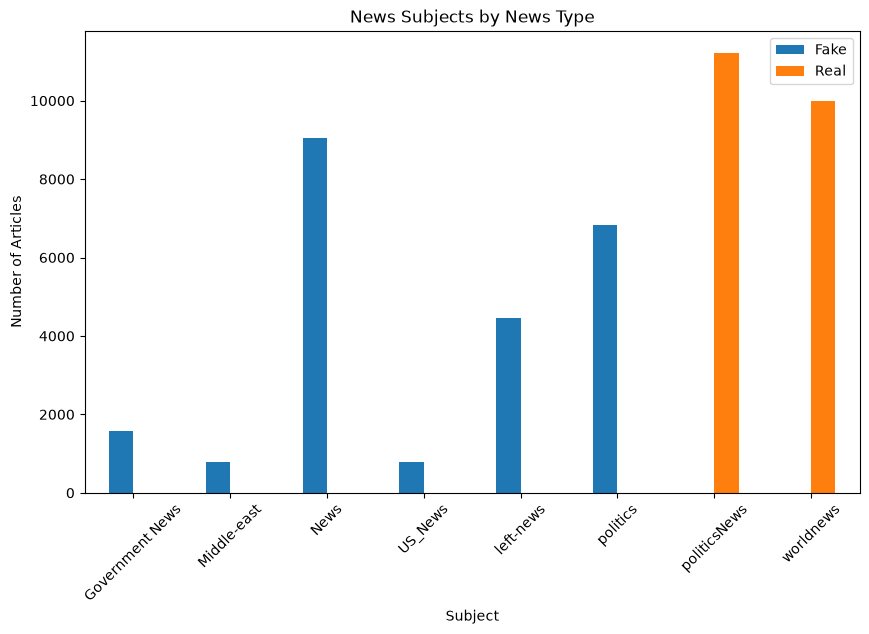

In [36]:
subject_label.plot(kind='bar', figsize=(10,6))
plt.title('News Subjects by News Type')
plt.xlabel('Subject')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.legend(['Fake', 'Real'])
plt.show()

In [37]:
print("Empty titles:", (df['title'].str.strip() == '').sum())
print("Empty texts:", (df['text'].str.strip() == '').sum())

Empty titles: 0
Empty texts: 631


In [38]:
print(pd.crosstab(df['label'],df['text'].str.strip().eq('')))

text   False  True 
label              
0      22848    630
1      21210      1


In [39]:
fake_text = ' '.join(df[df['label'] == 0]['text'].astype(str))
real_text = ' '.join(df[df['label'] == 1]['text'].astype(str))

In [40]:

fake_words = Counter(fake_text.lower().split())
real_words = Counter(real_text.lower().split())

In [41]:
print("Fake:", fake_words.most_common(20))
print("Real:", real_words.most_common(20))


Fake: [('the', 525499), ('to', 288545), ('of', 235142), ('and', 222323), ('a', 209585), ('in', 162835), ('that', 144891), ('s', 128330), ('is', 107714), ('for', 91063), ('on', 79828), ('he', 76895), ('it', 70356), ('was', 66940), ('trump', 65511), ('with', 62016), ('his', 57885), ('as', 55414), ('this', 51751), ('be', 47780)]
Real: [('the', 471986), ('to', 241454), ('of', 202253), ('a', 194234), ('and', 178653), ('in', 177291), ('on', 106376), ('that', 83948), ('for', 78206), ('said', 71167), ('is', 54062), ('with', 53452), ('he', 51889), ('was', 47143), ('by', 46939), ('as', 46282), ('has', 45455), ('s', 43871), ('it', 41361), ('from', 38719)]


## **5. Using NLP techniques**

In [42]:
df["tokens"]=df['text'].apply(word_tokenize)

In [43]:
word = set(stopwords.words("english"))
df["tokens"] = df["tokens"].apply(lambda words: [w for w in words if w.lower() not in word])

In [44]:
df["tokens"]=df["tokens"].apply(lambda words:[w for w in words if w.lower() not in word])

In [45]:
lemmatizer=WordNetLemmatizer()
df["tokens"]=df["tokens"].apply(lambda words:[lemmatizer.lemmatize(word) for word in words])

In [46]:
df['tokens'] = df['tokens'].apply(lambda x:' '.join(x))


In [47]:
print("Original:", len(df))
df=df.drop_duplicates(subset=["tokens"]).copy()
print("After removing duplicates:",len(df))

Original: 44689
After removing duplicates: 38639


## **6. Testing the data**

In [48]:
y=df["label"]
X=df["text"]

#### I used text instead tokens as a inpendent variable because tokens was not giving accurate results

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

## **7. Vectorizing the dataset**

In [50]:
tfidf=TfidfVectorizer()
X_train=tfidf.fit_transform(X_train)
X_test=tfidf.transform(X_test)

## **8. Logistic Regression**

In [51]:
model1=LogisticRegression()
model1.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [52]:
y1_pred=model1.predict(X_test)

In [53]:
acc1=accuracy_score(y_test,y1_pred)
pre1=precision_score(y_test,y1_pred)
rec1=recall_score(y_test,y1_pred)
f1=f1_score(y_test,y1_pred)
print("accuracy score:",acc1,"\nprecision score:",pre1,"\nrecall score:",rec1,"\nf1 score:",f1)

accuracy score: 0.9868012422360248 
precision score: 0.9827264239028944 
recall score: 0.9933931099575272 
f1 score: 0.9880309786435109


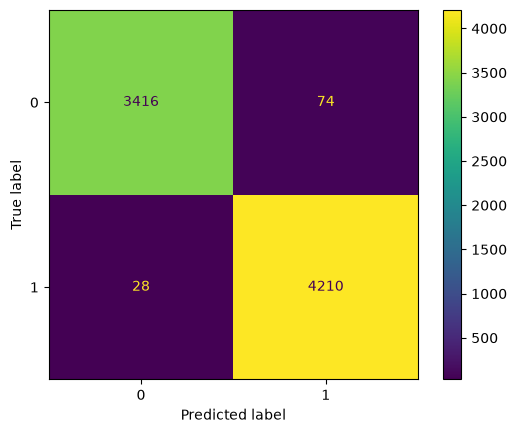

In [54]:
cm1= confusion_matrix(y_test, y1_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
plt.show()

## **9. Linear SVM**

In [55]:
model2=LinearSVC()
model2.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [56]:
y2_pred=model2.predict(X_test)

In [57]:
acc2=accuracy_score(y_test,y2_pred)
pre2=precision_score(y_test,y2_pred)
rec2=recall_score(y_test,y2_pred)
f2=f1_score(y_test,y2_pred)
print("accuracy score:",acc2,"\nprecision score:",pre2,"\nrecall score:",rec2,"\nf1 score:",f2)

accuracy score: 0.9937888198757764 
precision score: 0.9920150305307656 
recall score: 0.9966965549787635 
f1 score: 0.9943502824858758


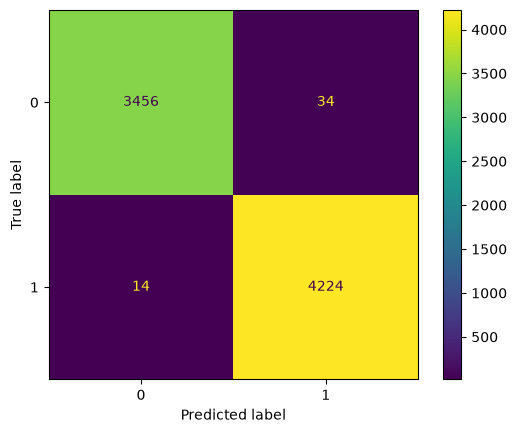

In [58]:
cm2= confusion_matrix(y_test, y2_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp.plot()
plt.show()

## **10. Random Forest Classifier**

In [59]:
model3=RandomForestClassifier(n_estimators=10,random_state=42,n_jobs=-1)
model3.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [60]:
y3_pred=model3.predict(X_test)

In [61]:
acc3=accuracy_score(y_test,y3_pred)
pre3=precision_score(y_test,y3_pred)
rec3=recall_score(y_test,y3_pred)
f3=f1_score(y_test,y3_pred)
print("accuracy score:",acc3,"\nprecision score:",pre3,"\nrecall score:",rec3,"\nf1 score:",f3)

accuracy score: 0.947851966873706 
precision score: 0.9606053326927696 
recall score: 0.9436054742803209 
f1 score: 0.9520295202952029


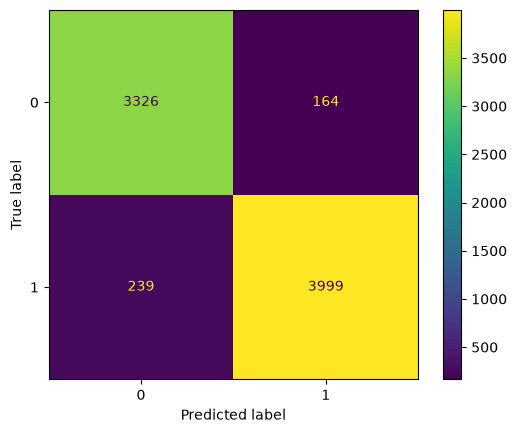

In [62]:
cm3= confusion_matrix(y_test, y3_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()
plt.show()

## **11. Multinomial Naiye Bayes**

In [63]:
model4=MultinomialNB()
model4.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[13960.,16951.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.79,-0.6 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 109017)","[[ 16.64, 61.95, 0.24,..., 0.11, 0.1 , 0. ], [ 3.82,114.23, 0.36,..., 0. , 0. , 0.07]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 109017)","[[ -9.6 , -8.32,-12.25,...,-12.36,-12.37,-12.47], [-10.98, -7.81,-12.25,...,-12.55,-12.55,-12.49]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,109017


In [64]:
y4_pred=model4.predict(X_test)

In [65]:
acc4=accuracy_score(y_test,y4_pred)
pre4=precision_score(y_test,y4_pred)
rec4=recall_score(y_test,y4_pred)
f4=f1_score(y_test,y4_pred)
print("accuracy score:",acc4,"\nprecision score:",pre4,"\nrecall score:",rec4,"\nf1 score:",f4)

accuracy score: 0.9396997929606625 
precision score: 0.9238202247191011 
recall score: 0.9700330344502124 
f1 score: 0.9463627992633518


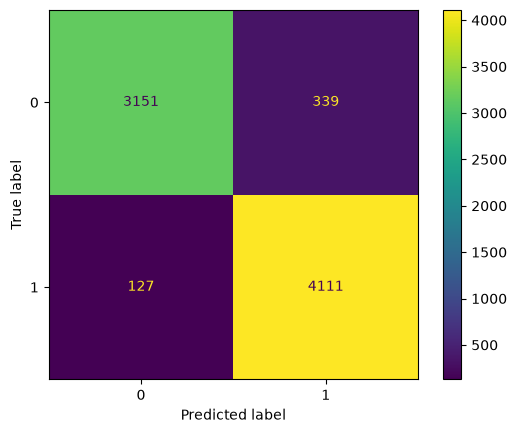

In [66]:
cm4= confusion_matrix(y_test, y4_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm4)
disp.plot()
plt.show()

## **12. XGBClassifier**

In [67]:
model5=XGBClassifier(n_estimators=100,random_state=42,n_jobs=-1)
model5.fit(X_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [68]:
y5_pred=model5.predict(X_test)

In [69]:
acc5=accuracy_score(y_test,y5_pred)
pre5=precision_score(y_test,y5_pred)
rec5=recall_score(y_test,y5_pred)
f5=f1_score(y_test,y5_pred)
print("accuracy score:",acc5,"\nprecision score:",pre5,"\nrecall score:",rec5,"\nf1 score:",f5)

accuracy score: 0.9970238095238095 
precision score: 0.9957657021877205 
recall score: 0.9988201982067013 
f1 score: 0.9972906113794322


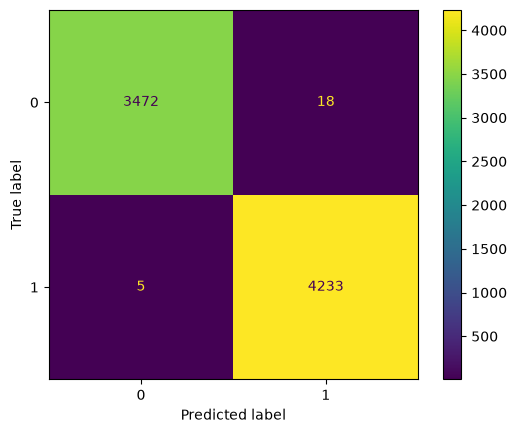

In [70]:
cm5= confusion_matrix(y_test, y5_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm5)
disp.plot()
plt.show()

## **13. Making a table for all models**

In [71]:
table=pd.DataFrame({"Models":["Logistic Regression","Linear SVC","Random Forest Classifier","Multinomial NB","XGB Classifier"],"Accuracy Score":[acc1,acc2,acc3,acc4,acc5],"Recall Score":[rec1,rec2,rec3,rec4,rec5],"Precision Score":[pre1,pre2,pre3,pre4,pre5],"Recall Score":[rec1,rec2,rec3,rec4,rec5],"f1 Score":[f1,f2,f3,f4,f5]})

In [72]:
table.iloc[:,1:] =table.iloc[:,1:]*100
table.round(2)

,Models,Accuracy Score,Recall Score,Precision Score,f1 Score
0,Logistic Regression,98.68,99.34,98.27,98.80
1,Linear SVC,99.38,99.67,99.20,99.44
2,Random Forest Classifier,94.79,94.36,96.06,95.20
3,Multinomial NB,93.97,97.00,92.38,94.64
4,XGB Classifier,99.70,99.88,99.58,99.73


## **14.Final Model Selection**

**Logistic Regression was selected as the final model because it provides predict_proba(), which supports the application's confidence score and low-confidence warning. Although tuned models achieved slightly higher test accuracy, Logistic Regression was a better fit for the application's requirements.**

## **15.Perfoming Hyperparameter Tuning**

In [73]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [1000, 2000]
}

In [ ]:
final_model = RandomizedSearchCV(
    estimator=model1,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)
final_model.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'max_iter': [1000, 2000], 'solver': ['liblinear', 'lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``

## **16.Why Not the Hyperparameter-Tuned Model?**

**The hyperparameter-tuned model achieved slightly higher test accuracy, but it was not selected because Logistic Regression better supports the application's confidence scoring through predict_proba() and met the deployment requirements.**

## **17. Transfering final model into another file**

In [82]:
joblib.dump(model1, "final_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")
model = joblib.load("final_model.pkl")
tfidf = joblib.load("tfidf.pkl")

## **18. Conclusion**

**The Fake News Checker successfully combines machine learning, NLP, Streamlit, and MySQL to predict whether a news article is likely real or fake. Logistic Regression was selected as the final model because it supports confidence scoring through predict_proba(). The application also provides user authentication, prediction history, and low-confidence warnings to encourage users to verify uncertain results.**